### Redes neuronales - Clasificación


In [ ]:
#Bloque de imports:

import numpy as np
import pandas as pd
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.utils import to_categorical
from keras.layers import BatchNormalization
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, train_test_split

plt.rcParams['figure.figsize'] = [3, 3]

In [ ]:
#Bloque de funciones:


# Cargar dataset y dividir en train / test
def cargar_dataset():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32')
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])

    trainX, testX, trainY, testY = train_test_split(
        datos,
        etiquetas,
        test_size=0.1,
        random_state=1,
        stratify=etiquetas
    )

    trainY = to_categorical(trainY, num_classes=5)
    testY = to_categorical(testY, num_classes=5)
    return trainX, trainY, testX, testY

# Normalización de tonos de pixel
def prep_pixels(train, test):
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm


def enriquecer_features(datos):
    bytes_originales = np.clip(np.rint(datos * 255), 0, 255).astype('uint8')
    
    # 1. Histograma global
    histogramas = np.array([np.bincount(f, minlength=256) / 512.0 for f in bytes_originales])
    
    # 2. Estadísticas
    estadisticas = np.column_stack([
        bytes_originales.mean(axis=1) / 255.0,
        bytes_originales.std(axis=1) / 255.0,
        bytes_originales.min(axis=1) / 255.0,
        bytes_originales.max(axis=1) / 255.0
    ])
    
    # 3. Histogramas por bloques
    bloques = bytes_originales.reshape(-1, 8, 64)
    histogramas_bloques = np.array([
        np.concatenate([np.bincount(b, minlength=256) / 64.0 for b in m])
        for m in bloques
    ])

    # 4. Transiciones (Volvemos a 256 para evitar ruido de dispersión)
    bytes_reducidos = bytes_originales // 16
    transiciones = bytes_reducidos[:, :-1] * 16 + bytes_reducidos[:, 1:]
    histogramas_transiciones = np.array([np.bincount(f, minlength=256) / 511.0 for f in transiciones])

    # 5. Entropía
    entropia = -np.sum(histogramas * np.log2(histogramas + 1e-9), axis=1, keepdims=True)

    # 6. Histograma de Diferencias Absolutas
    bytes_int = bytes_originales.astype('int16')
    diferencias = np.abs(bytes_int[:, 1:] - bytes_int[:, :-1]).astype('uint8')
    histogramas_diff = np.array([np.bincount(f, minlength=256) / 511.0 for f in diferencias])

	# 7. Transformada de Fourier (Espectro de Frecuencias)
    # RFFT devuelve 257 magnitudes de frecuencia para 512 bytes
    fft_magnitudes = np.abs(np.fft.rfft(datos, axis=1)) / 512.0

    return np.concatenate([
       # datos,                    # 512
        histogramas,              # 256
        estadisticas,             # 4
        histogramas_bloques,      # 2048
        histogramas_transiciones, # 256
        entropia,                 # 1
        histogramas_diff,          # 256
		fft_magnitudes            # 257
    ], axis=1)                    # TOTAL = 3590 características


# Graficar un fragmento de bytes
def graficar_uno(valor, conjunto, prediccion=None):
    plt.figure()
    plt.plot(conjunto[valor][:512])
    if prediccion is not None:
        plt.ylabel('Predicho: '+str(prediccion))
    return plt.show()

def predecir_con_ensamble(dataX, dataY, test_features_final, epocas=150):
    # Usamos 10 divisiones para el mega-ensamble
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    
    # Matriz para sumar las probabilidades de las 500 imágenes del test ciego
    probas_totales = np.zeros((len(test_features_final), 5))
    
    # Pesos de clase para forzar a la red a enfocarse en PNG y WEBP
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,  
            verbose=0 
        )
        
        probas_totales += modelo.predict(test_features_final, verbose=0)
        fold_actual += 1

    # Promediamos las probabilidades de los 10 modelos
    probas_promedio = probas_totales / 10.0
    
    clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
    predicciones_ensamble = [clases[i] for i in np.argmax(probas_promedio, axis=1)]
    
    return predicciones_ensamble

In [452]:
# Evaluador SIMPLE

def evaluar_modelo_simple(dataX,dataY,modelo,estadoaleatorio=1,epocas=10):
	scores, histories= list(),list()
	model = modelo()
	history = model.fit(trainX, trainY, epochs=epocas, batch_size=32, validation_data=(testX, testY), verbose=1)
	_, acc = model.evaluate(testX, testY, verbose=1)
	print('> %.3f' % (acc * 100.0))
	scores.append(acc)
	histories.append(history)
	return scores, histories, model

# Evaluación con k-fold cross-validation
def evaluar_modelo_kfold(dataX, dataY, modelo, n_folds=5, estadoaleatorio=1):
	scores, histories = list(), list()
	# preparar los k-fold
	kfold = KFold(n_folds, shuffle=True, random_state=estadoaleatorio)
	# Enumerar las divisiones
	for train_ix, test_ix in kfold.split(dataX):
		# definir model
		model = modelo()
		# elegir filas para train y validation
		trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]
		# fitear modelo
		history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)
		# evaluar modelo
		_, acc = model.evaluate(testX, testY, verbose=0)
		print('> %.3f' % (acc * 100.0))
		# guardar puntajes
		scores.append(acc)
		histories.append(history)
	return scores, histories, model

# Graficar diagnósticos
def diagnosticos(histories):
	for i in range(len(histories)):
		# graficar loss
		plt.subplot(2, 1, 1)
		plt.title('Cross Entropy Loss')
		plt.plot(histories[i].history['loss'], color='blue', label='train')
		plt.plot(histories[i].history['val_loss'], color='orange', label='test')
		# graficar accuracy
		plt.subplot(2, 1, 2)
		plt.title('Classification Accuracy')
		plt.plot(histories[i].history['accuracy'], color='blue', label='train')
		plt.plot(histories[i].history['val_accuracy'], color='orange', label='test')
	plt.show()

In [453]:
trainX, trainY, testX, testY = cargar_dataset()
trainX, testX = prep_pixels(trainX, testX)
trainX = enriquecer_features(trainX)
testX = enriquecer_features(testX)
print('Dimensiones trainX:', trainX.shape)
print('Dimensiones testX:', testX.shape)

Dimensiones trainX: (3600, 3078)
Dimensiones testX: (400, 3078)


In [454]:
def cargar_dataset_completo():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32') / 255.0
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])
    datos = enriquecer_features(datos)
    etiquetas = to_categorical(etiquetas, num_classes=5)
    return datos, etiquetas


def entrenar_modelo_completo(epocas):
    datos, etiquetas = cargar_dataset_completo()
    modelo_final = definir_modelo()
    modelo_final.fit(
        datos,
        etiquetas,
        epochs=epocas,
        batch_size=32,
        verbose=1
    )
    return modelo_final


def predecirparaunalista(redneuronalentrenada,conjunto=None):
    if conjunto is None:
        conjunto = testX
    puntajes = redneuronalentrenada.predict(conjunto)
    prediccion = np.zeros(len(conjunto), dtype=int)
    for x in range(len(conjunto)):
        prediccion[x] = np.argmax(puntajes[x])
    unique, counts = np.unique(prediccion,return_counts=True)
    return dict(zip(unique,counts))

def matrizdeconfusion(redneuronalentrenada,conjunto=None, targetsonehot=None, normalizar=False):
    if conjunto is None:
        conjunto = testX
    if targetsonehot is None:
        targetsonehot = testY

    puntajes = redneuronalentrenada.predict(conjunto, verbose=0)
    prediccion = np.argmax(puntajes, axis=1)
    objetivo = np.argmax(targetsonehot, axis=1)
    etiquetas = ['gif', 'jpg', 'png', 'qoi', 'webp']

    matriz = confusion_matrix(
        objetivo,
        prediccion,
        normalize='true' if normalizar else None
    )
    display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=etiquetas
    )
    display.plot(cmap='Blues', values_format='.2f' if normalizar else 'd')
    plt.title('Matriz de confusión')
    plt.show()


def find_non_equal_indices(list1, list2):
    non_equal_indices = []
    for i in range(min(len(list1), len(list2))):
        if list1[i] != list2[i]:
            non_equal_indices.append(i)
    return non_equal_indices

def listarerrores(adivinado,objetivo=testY):
    errores = find_non_equal_indices(adivinado,np.argmax(objetivo, axis = 1))
    return errores

In [455]:
print ("Tamaño de conjunto de entrenamiento: "+str(len(trainX)) + "\n"+"Tamaño de conjunto de test:          "+str(len(testX)))

Tamaño de conjunto de entrenamiento: 3600
Tamaño de conjunto de test:          400


In [456]:
plt.rcParams['figure.figsize'] = [3, 3]

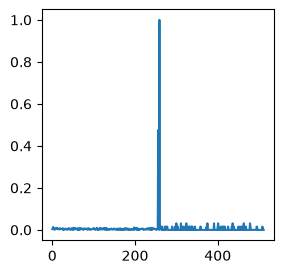

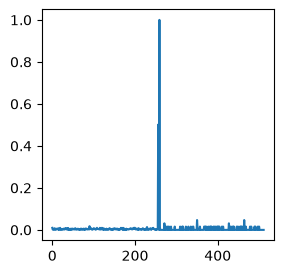

In [457]:
graficar_uno(315, trainX)
graficar_uno(100, testX)

In [458]:
# Modelo feedforward para clasificación

def definir_modelo():
    modelo = Sequential([
        keras.Input(shape=(3078,)),
        Dense(254, activation='swish'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='swish'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
        metrics=['accuracy']
    )
    return modelo

Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7425 - loss: 0.9413 - val_accuracy: 0.2000 - val_loss: 1.5506 - learning_rate: 0.0010
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9308 - loss: 0.6113 - val_accuracy: 0.3525 - val_loss: 1.4315 - learning_rate: 0.0010
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9664 - loss: 0.5406 - val_accuracy: 0.5050 - val_loss: 1.3219 - learning_rate: 0.0010
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9836 - loss: 0.5052 - val_accuracy: 0.6575 - val_loss: 1.0682 - learning_rate: 0.0010
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.4905 - val_accuracy: 0.7725 - val_loss: 0.8932 - learning_rate: 0.0010
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9928 - loss: 0.4765 - val_accuracy: 0.8225 - val_loss: 0.7757 - learning_rate: 0.0010
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9942 - loss: 0.

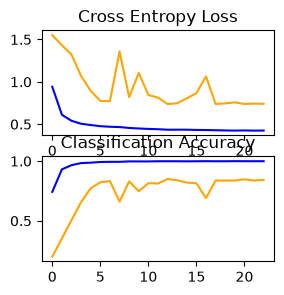

In [459]:
modelo_entrenado = definir_modelo()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.00001
)

# Entrenamiento y evaluación del modelo base
history = modelo_entrenado.fit(
    trainX,
    trainY,
    epochs=150,
    batch_size=32,
    validation_data=(testX, testY),
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

loss, accuracy = modelo_entrenado.evaluate(testX, testY, verbose=0)
print(f'Accuracy de validación: {accuracy * 100:.2f}%')
print("Épocas ejecutadas:", len(history.history["loss"]))
print("Mejor época por val_loss:", np.argmin(history.history["val_loss"]) + 1)
print("Mejor época por val_accuracy:", np.argmax(history.history["val_accuracy"]) + 1)

diagnosticos([history])

In [460]:
# Evaluación en test_publico.csv
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

publico_loss, publico_accuracy = modelo_entrenado.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy en test_publico: {publico_accuracy * 100:.2f}%')

print("Mejor train:", max(history.history["accuracy"]) * 100)
print("Mejor validación:", max(history.history["val_accuracy"]) * 100)
print("Test público:", publico_accuracy * 100)

Accuracy en test_publico: 82.40%
Mejor train: 99.97222423553467
Mejor validación: 85.00000238418579
Test público: 82.40000009536743


In [461]:
# Entrenamiento final con las 4000 muestras etiquetadas
epocas_finales = np.argmax(history.history['val_accuracy']) + 1
modelo_final = entrenar_modelo_completo(epocas_finales)

final_publico_loss, final_publico_accuracy = modelo_final.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy del modelo final en test_publico: {final_publico_accuracy * 100:.2f}%')

Epoch 1/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7465 - loss: 0.9277
Epoch 2/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9317 - loss: 0.5998
Epoch 3/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9592 - loss: 0.5453
Epoch 4/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.5134
Epoch 5/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9893 - loss: 0.4847
Epoch 6/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9885 - loss: 0.4799
Epoch 7/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9915 - loss: 0.4696
Epoch 8/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.4586
Epoch 9/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9960 - loss: 0.4561
Epoch 10/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9973 - loss: 0.4507
Epoch 11/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9960 - loss: 0.4510
Epoch 12/13
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

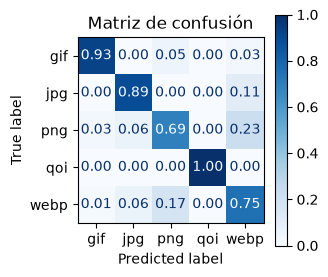

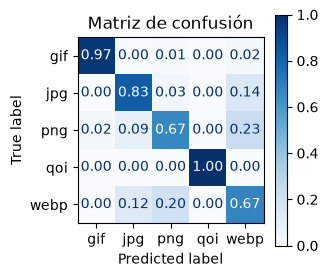

In [462]:
# Matriz de confusión sobre el conjunto de validación
matrizdeconfusion(modelo_entrenado, testX, testY, normalizar=True)

matrizdeconfusion(modelo_entrenado, publicoX,publicoY, normalizar=True)



In [464]:
from sklearn.model_selection import KFold


def predecir_con_ensamble(dataX, dataY, test_features_final, epocas=150):
    kfold = KFold(n_splits=10, shuffle=True, random_state=1)
    probas_totales = np.zeros((len(test_features_final), 5))
    
    # Índices: 'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4
    pesos_clases = {0: 1.0, 1: 1.5, 2: 3.0, 3: 1.0, 4: 3.0}
    
    fold_actual = 1
    for train_ix, val_ix in kfold.split(dataX):
        print(f"--- Entrenando Fold {fold_actual} de 10 ---")
        tX, vX = dataX[train_ix], dataX[val_ix]
        tY, vY = dataY[train_ix], dataY[val_ix]
        
        modelo = definir_modelo()
        modelo.fit(
            tX, tY, 
            epochs=epocas, 
            batch_size=32, 
            validation_data=(vX, vY),
            callbacks=[early_stop, reduce_lr], 
            class_weight=pesos_clases,  # <-- NUEVO: Forzamos el enfoque en las clases difíciles
            verbose=0 
        )
        
        probas_totales += modelo.predict(test_features_final, verbose=0)
        fold_actual += 1

    probas_promedio = probas_totales / 10.0
    clases = ['gif', 'jpg', 'png', 'qoi', 'webp']
    return [clases[i] for i in np.argmax(probas_promedio, axis=1)]

In [ ]:
# 1. Cargamos las 4000 filas completas de entrenamiento
datos_completos, etiquetas_completas = cargar_dataset_completo()

# 2. Cargamos el test público y aplicamos el mismo enriquecimiento
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)

# Extraemos las etiquetas reales del test público y las pasamos a one-hot
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

# 3. Ponemos a prueba el ensamble
print("Iniciando prueba del ensamble sobre test_publico...")
probas_ensamble_publico = evaluar_ensamble_publico(
    datos_completos, 
    etiquetas_completas, 
    publicoX, 
    publicoY
)

Iniciando prueba del ensamble sobre test_publico...
--- Entrenando Fold 1 de 5 ---
--- Entrenando Fold 2 de 5 ---
--- Entrenando Fold 3 de 5 ---
--- Entrenando Fold 4 de 5 ---
--- Entrenando Fold 5 de 5 ---
--- Entrenando Fold 6 de 5 ---
--- Entrenando Fold 7 de 5 ---
--- Entrenando Fold 8 de 5 ---
--- Entrenando Fold 9 de 5 ---
--- Entrenando Fold 10 de 5 ---

---> Accuracy final del Ensamble en test_publico: 83.60% <---


In [ ]:
# 1. Cargar las 4000 muestras completas con etiquetas
datos_completos, etiquetas_completas = cargar_dataset_completo()

# 2. Cargar y enriquecer el archivo final sin etiquetas (asegurándote de usar la última versión de enriquecer_features)
test_features = np.loadtxt(
    '../dataset/clasificacion_test_features.csv',
    delimiter=',',
    dtype='float32'
) / 255.0
test_features = enriquecer_features(test_features)
print('Dimensiones de test_features (debe ser 3078):', test_features.shape)

# 3. Correr el ensamble con los 10 folds
predicciones_finales = predecir_con_ensamble(datos_completos, etiquetas_completas, test_features)

# 4. Guardar la entrega final
pd.DataFrame({
    'y_pred': predicciones_finales
}).to_csv('entrega_clasificacion.csv', index=False)

